### IMPORT LIBRARIES

In [10]:
# Cell 1 - Setup
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("E:/new pro/train.csv", low_memory=False)
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


### sql Query: Average credit score by occupation

In [16]:


#encode Credit_Score numerically before loading into SQL
score_map = {'Poor': 1, 'Standard': 2, 'Good': 3}
df['Credit_Score_Num'] = df['Credit_Score'].map(score_map)

#reload into SQL with the new numeric column
conn = sqlite3.connect(':memory:')
df.to_sql('credit_data', conn, index=False, if_exists='replace')

#query using the numeric column
query1 = """
SELECT Occupation, 
       ROUND(AVG(Credit_Score_Num), 3) as Avg_Score,
       COUNT(*) as Count
FROM credit_data
GROUP BY Occupation
ORDER BY Avg_Score DESC
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

       Occupation  Avg_Score  Count
0   Media_Manager      1.922   6232
1      Journalist      1.909   6085
2       Architect      1.907   6355
3        Musician      1.905   5911
4          Doctor      1.905   6087
5          Lawyer      1.901   6575
6         Manager      1.894   5973
7       Developer      1.894   6235
8         _______      1.888   7062
9        Engineer      1.882   6350
10     Accountant      1.880   6271
11        Teacher      1.879   6215
12      Scientist      1.874   6299
13   Entrepreneur      1.868   6174
14       Mechanic      1.861   6291
15         Writer      1.840   5885


In [17]:
query1 = """
SELECT Occupation,
       COUNT(*) as Total_Customers,
       SUM(CASE WHEN Credit_Score = 'Good' THEN 1 ELSE 0 END) as Good_Score,
       SUM(CASE WHEN Credit_Score = 'Standard' THEN 1 ELSE 0 END) as Standard_Score,
       SUM(CASE WHEN Credit_Score = 'Poor' THEN 1 ELSE 0 END) as Poor_Score
FROM credit_data
GROUP BY Occupation
ORDER BY Good_Score DESC
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

       Occupation  Total_Customers  Good_Score  Standard_Score  Poor_Score
0         _______             7062        1243            3788        2031
1        Engineer             6350        1182            3236        1932
2      Journalist             6085        1173            3187        1725
3          Lawyer             6575        1162            3603        1810
4   Media_Manager             6232        1161            3426        1645
5       Architect             6355        1144            3477        1734
6         Teacher             6215        1143            3177        1895
7       Developer             6235        1134            3309        1792
8      Accountant             6271        1128            3264        1879
9       Scientist             6299        1127            3251        1921
10       Musician             5911        1110            3131        1670
11        Manager             5973        1098            3143        1732
12         Doctor        

###  SQL Query 2: Payment behavior analysis

In [18]:

query2 = """
SELECT Payment_Behaviour,
       Credit_Mix,
       COUNT(*) as Total_Customers,
       AVG(Outstanding_Debt) as Avg_Debt
FROM credit_data
GROUP BY Payment_Behaviour, Credit_Mix
ORDER BY Avg_Debt DESC
LIMIT 10
"""
result2 = pd.read_sql_query(query2, conn)
print(result2)

                  Payment_Behaviour Credit_Mix  Total_Customers     Avg_Debt
0   High_spent_Small_value_payments        Bad             2124  3018.575344
1    Low_spent_Small_value_payments        Bad             5987  3015.042228
2   High_spent_Large_value_payments        Bad             1858  3013.142546
3   Low_spent_Medium_value_payments        Bad             2634  3003.086560
4                            !@9#%8        Bad             1478  2995.229134
5    Low_spent_Large_value_payments        Bad             1951  2990.133250
6  High_spent_Medium_value_payments        Bad             2957  2982.023953
7    Low_spent_Small_value_payments          _             5241  1589.463545
8                            !@9#%8          _             1504  1419.550445
9   High_spent_Small_value_payments          _             2352  1410.275901


### Credit score distribution by occupation

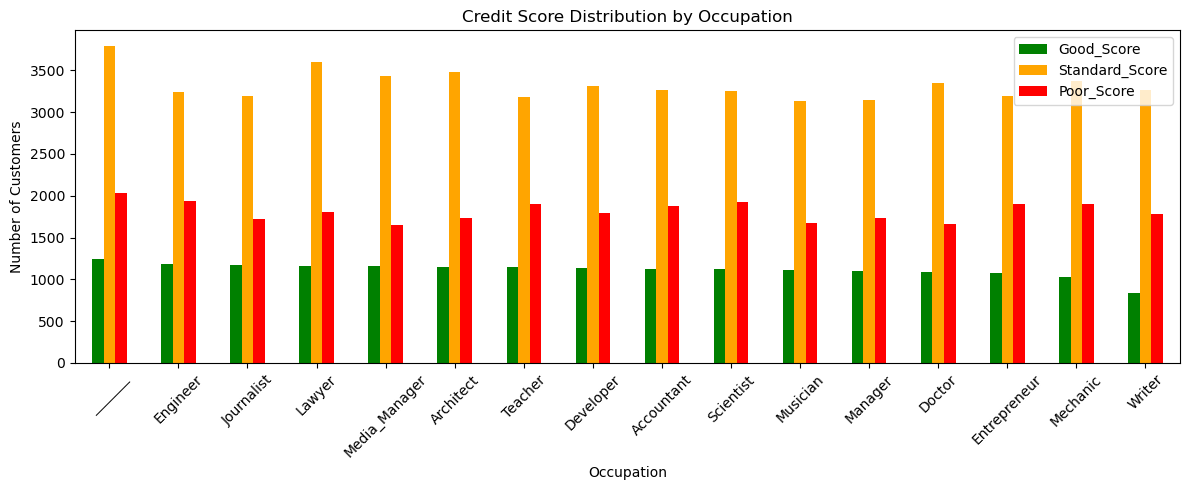

In [19]:
result1.plot(x='Occupation', y=['Good_Score', 'Standard_Score', 'Poor_Score'],
             kind='bar', figsize=(12,5),
             color=['green', 'orange', 'red'])
plt.title('Credit Score Distribution by Occupation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
